# Лабораторная работа 5. Классификация слов предложений на основе нейронной сети

Лабораторная работа составлена на основе [материала](https://colab.research.google.com/drive/1Pz8b_h-W9zIBk1p2e6v-YFYThG1NkYeS?usp=sharing) о PyTorch из [курса ](https://web.stanford.edu/class/cs224n/).

#### Работу выполнил: Самойло Александр, студент группы ФИб-4

Рассмотрим применение библиотеки PyTorch дл решения NLP задачи - классификация слов на класс именованной сущности Location (задача Name Entity Recognition, NER). Познакомимся со следующими этапами:

* Подготовка данных
* Моделирование
* Обучение
* Оценивание качества

**Постановка задачи**: нужно обучить модель  определять относится ли слово (с учётом его N-соседей в предложении) к названию местоположения (`LOCATION`).\
(!) Решаем задачу в условиях ограничения, что названия местоположений `LOCATION`, состоящих из нескольких слов, не учитываются.

In [ ]:
import torch
from torch import nn #все библиотеки для нейросетей

Исходный корпус:

In [2]:
corpus = [
          "We always come to Paris",
          "The professor is from Australia",
          "I live in Stanford",
          "He comes from Taiwan",
          "The capital of Turkey is Ankara"
         ]

Обучающие предложения разбьем по словам.

In [3]:
def preprocess_sentence(sentence):
  return sentence.lower().split()

train_sentences = [preprocess_sentence(sent) for sent in corpus]
train_sentences

[['we', 'always', 'come', 'to', 'paris'],
 ['the', 'professor', 'is', 'from', 'australia'],
 ['i', 'live', 'in', 'stanford'],
 ['he', 'comes', 'from', 'taiwan'],
 ['the', 'capital', 'of', 'turkey', 'is', 'ankara']]

Определим соответствующие метки (относится/не относится  слово к `LOCATION`) для слов обучающих предложений

In [4]:
locations = set(["australia", "ankara", "paris", "stanford", "taiwan", "turkey"])

train_labels = [[1 if word in locations else 0 for word in sent] for sent in train_sentences]
train_labels

[[0, 0, 0, 0, 1],
 [0, 0, 0, 0, 1],
 [0, 0, 0, 1],
 [0, 0, 0, 1],
 [0, 0, 0, 1, 0, 1]]

Составим словарь нашего корпуса

In [5]:
vocabulary = set(w for s in train_sentences for w in s)
vocabulary

{'always',
 'ankara',
 'australia',
 'capital',
 'come',
 'comes',
 'from',
 'he',
 'i',
 'in',
 'is',
 'live',
 'of',
 'paris',
 'professor',
 'stanford',
 'taiwan',
 'the',
 'to',
 'turkey',
 'we'}

Добавим специальный токен `<unk>` в словарь `vocabular`, который будет соответсвовать словам не из словаря.

In [6]:
vocabulary.add("<unk>")

Модель, которую будем обучать, будет смотреть не на всё предложение или на текст, а на окно слов (Word Window) в предложении. Окном яляется последовательность из слова и его N-соседей слева и справа.

Например:\
при N=2 для слова `Turkey` в предложении `The capital of Turkey is Ankara` окно будет `capital of Turkey is Ankara`.

Чтобы для слов, стоящих в начале и конце предложения, находились слова-соседи добавим в словарь `vocabular` токен `<pad>`.

In [7]:
vocabulary.add("<pad>")

In [8]:
def pad_window(sentence, window_size, pad_token="<pad>"):
  window = [pad_token] * window_size
  return window + sentence + window

window_size = 2
pad_window(train_sentences[0], window_size=window_size)

['<pad>', '<pad>', 'we', 'always', 'come', 'to', 'paris', '<pad>', '<pad>']

Отсортируем словарь и назначим каждому токену (слову) его индекс.

In [9]:
ix_to_word = sorted(list(vocabulary))

word_to_ix = {word: ind for ind, word in enumerate(ix_to_word)}
word_to_ix

{'<pad>': 0,
 '<unk>': 1,
 'always': 2,
 'ankara': 3,
 'australia': 4,
 'capital': 5,
 'come': 6,
 'comes': 7,
 'from': 8,
 'he': 9,
 'i': 10,
 'in': 11,
 'is': 12,
 'live': 13,
 'of': 14,
 'paris': 15,
 'professor': 16,
 'stanford': 17,
 'taiwan': 18,
 'the': 19,
 'to': 20,
 'turkey': 21,
 'we': 22}

In [10]:
ix_to_word[1]

'<unk>'

Теперь можно преобразовать обучающие предложения в последовательность индексов, соответствующих каждому токену.

In [12]:
def convert_token_to_indices(sentence, word_to_ix):
  indices = []
  for token in sentence:
    if token in word_to_ix:
      index = word_to_ix[token]
    else:
      index = word_to_ix["<unk>"]
    indices.append(index)
  return indices

Эта же функция преобразования предложения в последовательность индекстов словаря токенов, но в компактном виде

In [ ]:
def _convert_token_to_indices(sentence, word_to_ix):
  return [word_to_ind.get(token, word_to_ix["<unk>"]) for token in sentence]

Пример преобразования список слов в список соответсвующих индексов и обратно.

In [13]:
example_sentence = ["we", "always", "come", "to", "kuwait"]
example_indices = convert_token_to_indices(example_sentence, word_to_ix)
restored_example = [ix_to_word[ind] for ind in example_indices]

print(f"Original sentence is: {example_sentence}")
print(f"Going from words to indices: {example_indices}")
print(f"Going from indices to words: {restored_example}")

Original sentence is: ['we', 'always', 'come', 'to', 'kuwait']
Going from words to indices: [22, 2, 6, 20, 1]
Going from indices to words: ['we', 'always', 'come', 'to', '<unk>']


Построим для каждого обучающего предложения массив из соответсвующих индексов.

In [14]:
example_padded_indices = [convert_token_to_indices(s, word_to_ix) for s in train_sentences]
example_padded_indices

[[22, 2, 6, 20, 15],
 [19, 16, 12, 8, 4],
 [10, 13, 11, 17],
 [9, 7, 8, 18],
 [19, 5, 14, 21, 12, 3]]

Создадим таблицу эмбеддингов (для представления слов в виде векторов), которую представим в виде специального слоя `nn.Embedding(num_words, embedding_dimension)`, где `num_words` - количество слов в словаре, `embedding_dimension` - размерность вектора представления. Начальные значения таблицы выбираются случайным образом. Параметры этого слоя будут меняться по мере обучения нейронной сети на решаемой задаче и векторные представления будут улучшаться относительно решаемой задачи.

In [15]:
embedding_dim = 5
embeds = nn.Embedding(len(vocabulary), embedding_dim)

list(embeds.named_parameters())

[('weight',
  Parameter containing:
  tensor([[ 1.7465,  0.6932,  0.0591, -1.3824, -0.2771],
          [-1.0752,  1.4576, -2.8367,  0.9338, -0.3389],
          [ 0.3967, -0.6133,  1.8716,  0.9230,  0.3937],
          [-0.5667, -0.4130,  0.4485, -0.2758,  0.3999],
          [-1.0418, -0.8617, -0.2201,  0.6077, -0.6160],
          [ 1.9540,  0.3487,  0.8346, -0.6519,  0.0820],
          [ 0.5652,  0.5146,  0.0285, -0.5609, -0.1595],
          [ 1.0266,  0.8384,  0.7373, -0.5574, -0.5671],
          [-0.6080,  0.5372,  0.7620,  0.0200, -2.2312],
          [ 0.1526,  0.4959,  0.5286,  0.6054, -1.4474],
          [ 0.1763, -0.0610, -0.5635, -0.1553, -0.2453],
          [-1.1184,  0.2844,  0.0702, -0.8534,  0.4275],
          [ 0.1885,  0.5506,  1.1263, -0.4838,  0.8509],
          [-1.1791,  0.2540, -0.5695, -2.4527, -1.1964],
          [ 1.3905,  2.2300, -0.0164,  1.9749,  0.9482],
          [-2.5943, -1.5975, -0.6239,  0.1328,  0.2277],
          [ 2.3996,  0.1702, -0.5530, -0.0828,  0.01

Пример векторного представления для слова `paris`.

In [16]:
index = word_to_ix["paris"]
print(f"Индекс для слова `paris`: {index}")
index_tensor = torch.tensor(index, dtype=torch.long)
print(f"Тензор для индекса: {index_tensor}")
paris_embed = embeds(index_tensor)
print(f"Векторное представление для слова `paris`: {paris_embed}")
paris_embed

Индекс для слова `paris`: 15
Тензор для индекса: 15
Векторное представление для слова `paris`: tensor([-2.5943, -1.5975, -0.6239,  0.1328,  0.2277],
       grad_fn=<EmbeddingBackward0>)


tensor([-2.5943, -1.5975, -0.6239,  0.1328,  0.2277],
       grad_fn=<EmbeddingBackward0>)

Можно получать векторые представления для нескольких слов (предложения, текста)

In [17]:
index_paris = word_to_ix["paris"]
index_ankara = word_to_ix["ankara"]
indices = [index_paris, index_ankara]
indices_tensor = torch.tensor(indices, dtype=torch.long)
embeddings = embeds(indices_tensor)
embeddings

tensor([[-2.5943, -1.5975, -0.6239,  0.1328,  0.2277],
        [-0.5667, -0.4130,  0.4485, -0.2758,  0.3999]],
       grad_fn=<EmbeddingBackward0>)

Обычно слой эмбеддингов определяют как часть обучаемой модели.

Загрузка данных в модель обычно происходит батчами (пакетами). Для этого используется специальный класс `torch.util.data.DataLoader`.

Будем вызывать данный класс как `DataLoader(data, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)`. Аргумент `batch_size` - определяет размер порции данных, которая будет отсылаться за один шаг. Аргумент `shuffle` отвечает за перемешивание данных, а `collate_fn` - определяет функцию для дополнительной обработки батча.

In [18]:
from torch.utils.data import DataLoader
from functools import partial

def custom_collate_fn(batch, window_size, word_to_ix):

  def pad_window(sentence, window_size, pad_token="<pad>"):
    window = [pad_token] * window_size
    return window + sentence + window

  def convert_tokens_to_indices(sentence, word_to_ix):
    return [word_to_ix.get(token, word_to_ix["<unk>"]) for token in sentence]

  # Prepare the datapoints
  x, y = zip(*batch)
  x = [pad_window(s, window_size=window_size) for s in x]
  x = [convert_tokens_to_indices(s, word_to_ix) for s in x]

  # Pad x so that all the examples in the batch have the same size
  pad_token_ix = word_to_ix["<pad>"]
  x = [torch.LongTensor(x_i) for x_i in x]
  x_padded = nn.utils.rnn.pad_sequence(x, batch_first=True, padding_value=pad_token_ix)

  # Pad y and record the length
  lengths = [len(label) for label in y]
  lenghts = torch.LongTensor(lengths)
  y = [torch.LongTensor(y_i) for y_i in y]
  y_padded = nn.utils.rnn.pad_sequence(y, batch_first=True, padding_value=0)

  return x_padded, y_padded, lenghts

Запустим `DataLoader` и посмотрим данные для обучения.

In [19]:
data = list(zip(train_sentences, train_labels))
batch_size = 2
shuffle = True
window_size = 2
collate_fn = partial(custom_collate_fn, window_size=window_size, word_to_ix=word_to_ix)

loader = DataLoader(data, batch_size=batch_size, shuffle=shuffle, collate_fn=collate_fn)

counter = 0
for batched_x, batched_y, batched_lengths in loader:
  print(f"Iteration {counter}")
  print("Batched Input:")
  print(batched_x)
  print("Batched Labels:")
  print(batched_y)
  print("Batched Lengths:")
  print(batched_lengths)
  print("")
  counter += 1

Iteration 0
Batched Input:
tensor([[ 0,  0, 19, 16, 12,  8,  4,  0,  0],
        [ 0,  0, 10, 13, 11, 17,  0,  0,  0]])
Batched Labels:
tensor([[0, 0, 0, 0, 1],
        [0, 0, 0, 1, 0]])
Batched Lengths:
tensor([5, 4])

Iteration 1
Batched Input:
tensor([[ 0,  0, 22,  2,  6, 20, 15,  0,  0],
        [ 0,  0,  9,  7,  8, 18,  0,  0,  0]])
Batched Labels:
tensor([[0, 0, 0, 0, 1],
        [0, 0, 0, 1, 0]])
Batched Lengths:
tensor([5, 4])

Iteration 2
Batched Input:
tensor([[ 0,  0, 19,  5, 14, 21, 12,  3,  0,  0]])
Batched Labels:
tensor([[0, 0, 0, 1, 0, 1]])
Batched Lengths:
tensor([6])



Батчи, которые вывелись выше будут передаваться в модель. По заданию модель должна смотреть на текстовое окно и классифицировать его, относится ли центральное слово окна к `LOCATION`. Для этого из предложений нужно выделять данные окна.

In [20]:
# Исходный тензор
print(f"Original Tensor: ")
print(batched_x)
print("")

# Создание окон из предложения
chunk = batched_x.unfold(1, window_size*2 + 1, 1)
print(f"Windows: ")
print(chunk)

Original Tensor: 
tensor([[ 0,  0, 19,  5, 14, 21, 12,  3,  0,  0]])

Windows: 
tensor([[[ 0,  0, 19,  5, 14],
         [ 0, 19,  5, 14, 21],
         [19,  5, 14, 21, 12],
         [ 5, 14, 21, 12,  3],
         [14, 21, 12,  3,  0],
         [21, 12,  3,  0,  0]]])


Теперь создадим модель нейронной сети.

In [ ]:
class WordWindowClassifier(nn.Module):

  def __init__(self, hyperparameters, vocab_size, pad_ix=0):
    super(WordWindowClassifier, self).__init__()

    """ Instance variables """
    self.window_size = hyperparameters["window_size"]
    self.embed_dim = hyperparameters["embed_dim"]
    self.hidden_dim = hyperparameters["hidden_dim"]
    self.freeze_embeddings = hyperparameters["freeze_embeddings"]

    """ Embedding Layer
    Takes in a tensor containing embedding indices, and returns the
    corresponding embeddings. The output is of dim
    (number_of_indices * embedding_dim).

    If freeze_embeddings is True, set the embedding layer parameters to be
    non-trainable. This is useful if we only want the parameters other than the
    embeddings parameters to change.

    """
    self.embeds = nn.Embedding(vocab_size, self.embed_dim, padding_idx=pad_ix) #таблица со словами, всегда выдавай нули для нулей (последний арг.)
    if self.freeze_embeddings:
      self.embed_layer.weight.requires_grad = False

    """ Hidden Layer
    """
    full_window_size = 2 * window_size + 1
    self.hidden_layer = nn.Sequential(
      nn.Linear(full_window_size * self.embed_dim, self.hidden_dim), #берём все векторы слов из окна и склеиваем в одну линию и сжимаем
      nn.Tanh()  #активатор, чтобы сеть не была линейной
    ) 

    """ Output Layer
    """
    self.output_layer = nn.Linear(self.hidden_dim, 1) #выходной слой что превращает мысль из скрытого слоя в число, которое будет интерпретироваться как вероятность

    """ Probabilities
    """
    self.probabilities = nn.Sigmoid() #если вероятность > 0.5, то класс Location, иначе класс 0 - not Location

  def forward(self, inputs):
    """
    Let B:= batch_size
        L:= window-padded sentence length
        D:= self.embed_dim
        S:= self.window_size
        H:= self.hidden_dim

    inputs: a (B, L) tensor of token indices
    """
    B, L = inputs.size()

    """
    Reshaping.
    Takes in a (B, L) LongTensor
    Outputs a (B, L~, S) LongTensor
    """
    # нарезка предложений на скользящие, сколько слов столько и окон, каждое окно - это 2*S + 1 слов
    token_windows = inputs.unfold(1, 2 * self.window_size + 1, 1)
    _, adjusted_length, _ = token_windows.size()

    # Good idea to do internal tensor-size sanity checks, at the least in comments!
    assert token_windows.size() == (B, adjusted_length, 2 * self.window_size + 1)

    """
    Embedding.
    Takes in a torch.LongTensor of size (B, L~, S)
    Outputs a (B, L~, S, D) FloatTensor.
    """
    embedded_windows = self.embeds(token_windows) #все индексы из окон превращаются в векторы, 
    # размерность которых self.embed_dim

    """
    Reshaping.
    Takes in a (B, L~, S, D) FloatTensor.
    Resizes it into a (B, L~, S*D) FloatTensor.
    -1 argument "infers" what the last dimension should be based on leftover axes.
    """
    embedded_windows = embedded_windows.view(B, adjusted_length, -1)
    #было 5 векторов по размеру окна, каждый имел размер D, теперь подаем на вход сети один вектор, который получился из склейки этих 5 векторов, его размер S*D
    """
    Layer 1.
    Takes in a (B, L~, S*D) FloatTensor.
    Resizes it into a (B, L~, H) FloatTensor
    """
    layer_1 = self.hidden_layer(embedded_windows)#нейросеть ищет признаки в окне, которые могут помочь отличить класс Location от класса Not Location

    """
    Layer 2
    Takes in a (B, L~, H) FloatTensor.
    Resizes it into a (B, L~, 1) FloatTensor.
    """
    output = self.output_layer(layer_1) #выдача числа

    """
    Softmax.
    Takes in a (B, L~, 1) FloatTensor of unnormalized class scores.
    Outputs a (B, L~, 1) FloatTensor of (log-)normalized class scores.
    """
    output = self.probabilities(output)#вероятность от 0 до 1
    output = output.view(B, -1)

    return output

Выполним подготовку для обучения модели.

In [22]:
data = list(zip(train_sentences, train_labels))
batch_size = 2
shuffle = True
window_size = 2
collate_fn = partial(custom_collate_fn, window_size=window_size, word_to_ix=word_to_ix)

loader = DataLoader(data, batch_size=batch_size, shuffle=shuffle, collate_fn=collate_fn)

model_hyperparameters = {
    "batch_size": 4,
    "window_size": 2,
    "embed_dim": 25,
    "hidden_dim": 25,
    "freeze_embeddings": False,
}

vocab_size = len(word_to_ix)
model = WordWindowClassifier(model_hyperparameters, vocab_size)

learning_rate = 0.01
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

# Определим функцию потерь
def loss_function(batch_outputs, batch_labels, batch_lengths):
    # Вычисление ошибки по всему батчу
    bceloss = nn.BCELoss()
    loss = bceloss(batch_outputs, batch_labels.float())

    # Масштабирование ошибки относительно количества слов в батче
    loss = loss / batch_lengths.sum().float()

    return loss

Определим функцию обучения и функцию обучения на одной эпохе.

In [ ]:
def train_epoch(loss_function, optimizer, model, loader):
  total_loss = 0
  for batch_inputs, batch_labels, batch_lengths in loader:
    # зануляем старые градиенты
    optimizer.zero_grad()
    #прогоняем данные ерез модель через прямой проход
    outputs = model.forward(batch_inputs)
    # считаем ошибку
    loss = loss_function(outputs, batch_labels, batch_lengths)
    # обратный проход
    loss.backward()
    # шаг оптимизатора
    optimizer.step()
    total_loss += loss.item()

  return total_loss


def train(loss_function, optimizer, model, loader, num_epochs=10000):
  for epoch in range(num_epochs):
    epoch_loss = train_epoch(loss_function, optimizer, model, loader)
    if epoch % 100 == 0: print(f"Value loss on {epoch} is {epoch_loss}")

Запустим обучение модели.

In [24]:
num_epochs = 1000
train(loss_function, optimizer, model, loader, num_epochs=num_epochs)

Value loss on 0 is 0.28839055821299553
Value loss on 100 is 0.24598870053887367
Value loss on 200 is 0.2041068896651268
Value loss on 300 is 0.15567106753587723
Value loss on 400 is 0.1370782032608986
Value loss on 500 is 0.09915686585009098
Value loss on 600 is 0.08861817046999931
Value loss on 700 is 0.06440116092562675
Value loss on 800 is 0.054083299823105335
Value loss on 900 is 0.04323829337954521


Теперь для проверки обученой модели нужны тестовые данные.

In [25]:
# Create test sentences
test_corpus = ["I was born in Kirov", "Paris is a capital of France"]
test_sentences = [s.lower().split() for s in test_corpus]
test_labels = [[0, 0, 0, 0, 1], [1, 0, 0, 0, 0, 1]]

# Create a test loader
test_data = list(zip(test_sentences, test_labels))
batch_size = 1
shuffle = False
window_size = 2
collate_fn = partial(custom_collate_fn, window_size=2, word_to_ix=word_to_ix)
test_loader = torch.utils.data.DataLoader(test_data,
                                           batch_size=1,
                                           shuffle=False,
                                           collate_fn=collate_fn)

In [26]:
for x in test_loader:
  print(x)

(tensor([[ 0,  0, 10,  1,  1, 11,  1,  0,  0]]), tensor([[0, 0, 0, 0, 1]]), tensor([5]))
(tensor([[ 0,  0, 15, 12,  1,  5, 14,  1,  0,  0]]), tensor([[1, 0, 0, 0, 0, 1]]), tensor([6]))


In [27]:
for test_instance, labels, _ in test_loader:
  outputs = model.forward(test_instance)
  print(f"Истинные метки: {labels}")
  print(f"Предсказанные p(w is `LOCATION`):\n{outputs}")
  print('*'*32)

Истинные метки: tensor([[0, 0, 0, 0, 1]])
Предсказанные p(w is `LOCATION`):
tensor([[0.1720, 0.2245, 0.3918, 0.1718, 0.1575]], grad_fn=<ViewBackward0>)
********************************
Истинные метки: tensor([[1, 0, 0, 0, 0, 1]])
Предсказанные p(w is `LOCATION`):
tensor([[0.7863, 0.1176, 0.0440, 0.4163, 0.0517, 0.8258]],
       grad_fn=<ViewBackward0>)
********************************


**Задание 1.** Проанализируйте результаты предсказаний обученной модели на новых данных. В каких случаях модель более уверена в своих ответах?

In [ ]:
'''
Модель демонстрирует высокую уверенность (вероятности 0.78 и 0.82) на словах Paris и France, 
которые присутствовали в обучающей выборке или имеют сильный контекстный маркер.
Это говорит о том, что нейронная сеть успешно выучила признаки географических объектов в подобных конструкциях.

ПНа слове Kirov (которого не было в обучающем корпусе) модель показала низкую вероятность (0.15),
не классифицировав его как LOCATION. Это указывает на то, что модель сильно опирается на выученные эмбеддинги
конкретных слов, а не на обобщенные синтаксические признаки.

Модель лучше работает с уже знакомыми сущностями. Для улучшения работы с новыми словами (как Kirov)
необходимо увеличить объем обучающего корпуса или использовать более продвинутые методы,
например, предобученные эмбеддинги, которые содержат знания о языке в целом.
'''

**Задание 2.** Меняя размерность векторных представлений (эмбеддингов) у модели (нужно будет создать и обучить несколько экземпляров класса модели), проанализируйте качество обучения в случае когда векторные представления имеют меньшую и большую размерность, чем в текущем руководстве (например, 5 и 50). Визуализируйте результаты.

In [ ]:
def train(loss_function, optimizer, model, loader, num_epochs=10000):
  history = []
  for epoch in range(num_epochs):
    epoch_loss = train_epoch(loss_function, optimizer, model, loader)
    history.append(epoch_loss)
    if epoch % 100 == 0: print(f"Value loss on {epoch} is {epoch_loss}")
  return history #список суммарных ошибок по эпохам

In [31]:
'''model_hyperparameters = {
    "batch_size": 4,
    "window_size": 2,
    "embed_dim": 5,
    "hidden_dim": 25,
    "freeze_embeddings": False,
}'''

results = {} # сохранение loss по эпохам для разных embed_dim

for dim in [5, 50]:
    print(f"Обучаем модель с embed_dim = {dim}")
    
    model_hyperparameters["embed_dim"] = dim

    model = WordWindowClassifier(model_hyperparameters, vocab_size)
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
    
    history = train(loss_function, optimizer, model, loader, num_epochs=500)
    
    results[dim] = history


Обучаем модель с embed_dim = 5
Value loss on 0 is 0.2951519787311554
Value loss on 100 is 0.25451089441776276
Value loss on 200 is 0.24770154803991318
Value loss on 300 is 0.19940651953220367
Value loss on 400 is 0.18378935009241104
Обучаем модель с embed_dim = 50
Value loss on 0 is 0.3203941434621811
Value loss on 100 is 0.2051062434911728
Value loss on 200 is 0.14653604105114937
Value loss on 300 is 0.09193569794297218
Value loss on 400 is 0.058286028914153576


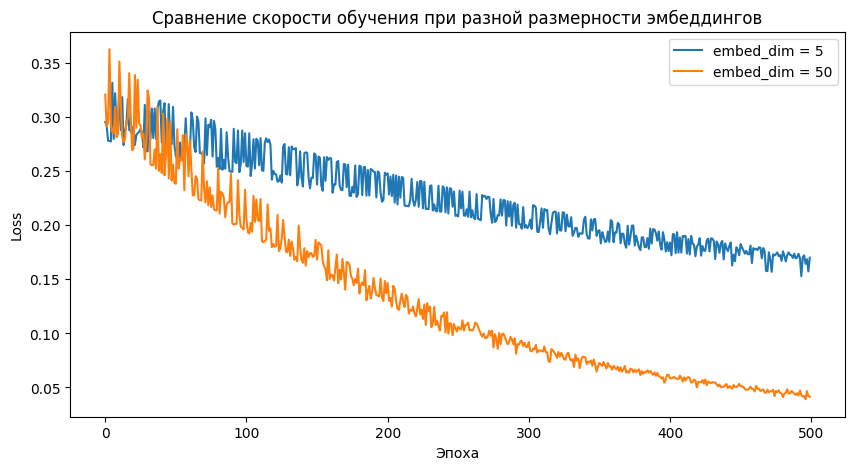

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(results[5], label='embed_dim = 5')
plt.plot(results[50], label='embed_dim = 50')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.title('Сравнение скорости обучения при разной размерности эмбеддингов')
plt.show()

In [ ]:
'''
Модель с большей размерностью эмбеддингов (embed_dim = 50)
показывает значительно более низкий итоговый loss и быстрее сходится, чем модель с размерностью 5.

Размерность 5 слишком мала, чтобы «упаковать» в векторы все нюансы смысла слов из словаря.
Размерность 50 предоставляет модели больше «пространства» для формирования уникальных и точных представлений
для каждого слова, что позволяет лучше разделять классы (LOCATION vs not LOCATION).
'''

**Задание 3.** Подготовьте данные из 25 предложений на русском языке с наличием слов, относящихся к именнованной сущности `ORGANIZATION` (20 для обучения и 5 для тестирования). При составлении предложений можно использовать сгенерированные вручную тексты. Автоматизируйте процесс создания корпуса, а точнее его разметки, например можно задать словарь организаций, а метки класса расставлять в цикле при проходе по словам, выполняя проверку входит ли начальная форма слова в словарь организаций.\
Создайте и обучите модель задаче классификации слова на класс именованной сущности `ORGANIZATION`. Подберите наиболее оптимальные гиперпараметры обучения. Визуализируйте процесс обучения (постройте графики loss). Проанализируйте качество предсказаний модели и сделайте выводы.

In [33]:
org_list = ["газпром", "яндекс", "сбербанк", "мгу", "росатом", "вк", "аэрофлот"] #словарь организаций

raw_corpus_ru = [
    "газпром строит новый завод",
    "яндекс выпустил новый телефон",
    "студент учится в мгу",
    "сбербанк открыл офис",
    "росатом занимается энергией",
    "вк запустил новую ленту",
    "аэрофлот купил самолеты",
    "я работаю в газпром",
    "мгу это лучший вуз",
    "яндекс это поисковик",
    "студенты из мгу отправились на практику",
    "практика проходила в росатом",
    "спонсоры из вк поддержали мероприятие",
    "газпром и аэрфлот хотели переманить их к себе",
    "но яндекс выпустил специальные акции для студентов мгу",
    "сбербанк предложил яндекс объединиться",
    "аэрофлот недоволен предложением сбербанка",
    "мгу решили не заключать партнерство",
    "росатом вложился в проект",
    "яндекс преостановил кластер",
    "вк переманили специалистов",
    "росатом отказался от практики",
    "мгу недовольно решением",
    "газпром все же приютил специалистов",
    "аэрофлот уволил сотрудников",
    "мама мыла раму",
    "город красивый",
    "он пошел в магазин",
    "кофе очень вкусный",
    "погода сегодня теплая"
]

In [34]:
train_s_new = [preprocess_sentence(sent) for sent in  raw_corpus_ru]
train_s_new

[['газпром', 'строит', 'новый', 'завод'],
 ['яндекс', 'выпустил', 'новый', 'телефон'],
 ['студент', 'учится', 'в', 'мгу'],
 ['сбербанк', 'открыл', 'офис'],
 ['росатом', 'занимается', 'энергией'],
 ['вк', 'запустил', 'новую', 'ленту'],
 ['аэрофлот', 'купил', 'самолеты'],
 ['я', 'работаю', 'в', 'газпром'],
 ['мгу', 'это', 'лучший', 'вуз'],
 ['яндекс', 'это', 'поисковик'],
 ['студенты', 'из', 'мгу', 'отправились', 'на', 'практику'],
 ['практика', 'проходила', 'в', 'росатом'],
 ['спонсоры', 'из', 'вк', 'поддержали', 'мероприятие'],
 ['газпром', 'и', 'аэрфлот', 'хотели', 'переманить', 'их', 'к', 'себе'],
 ['но',
  'яндекс',
  'выпустил',
  'специальные',
  'акции',
  'для',
  'студентов',
  'мгу'],
 ['сбербанк', 'предложил', 'яндекс', 'объединиться'],
 ['аэрофлот', 'недоволен', 'предложением', 'сбербанка'],
 ['мгу', 'решили', 'не', 'заключать', 'партнерство'],
 ['росатом', 'вложился', 'в', 'проект'],
 ['яндекс', 'преостановил', 'кластер'],
 ['вк', 'переманили', 'специалистов'],
 ['росатом',

In [35]:
organizations = set(org_list)

train_labels_new = [[1 if word in organizations else 0 for word in sent] for sent in train_s_new]
train_labels_new

[[1, 0, 0, 0],
 [1, 0, 0, 0],
 [0, 0, 0, 1],
 [1, 0, 0],
 [1, 0, 0],
 [1, 0, 0, 0],
 [1, 0, 0],
 [0, 0, 0, 1],
 [1, 0, 0, 0],
 [1, 0, 0],
 [0, 0, 1, 0, 0, 0],
 [0, 0, 0, 1],
 [0, 0, 1, 0, 0],
 [1, 0, 0, 0, 0, 0, 0, 0],
 [0, 1, 0, 0, 0, 0, 0, 1],
 [1, 0, 1, 0],
 [1, 0, 0, 0],
 [1, 0, 0, 0, 0],
 [1, 0, 0, 0],
 [1, 0, 0],
 [1, 0, 0],
 [1, 0, 0, 0],
 [1, 0, 0],
 [1, 0, 0, 0, 0],
 [1, 0, 0],
 [0, 0, 0],
 [0, 0],
 [0, 0, 0, 0],
 [0, 0, 0],
 [0, 0, 0]]

In [37]:
vocabulary_new = set(w for s in train_s_new for w in s)
vocabulary_new

{'акции',
 'аэрофлот',
 'аэрфлот',
 'в',
 'вк',
 'вкусный',
 'вложился',
 'все',
 'вуз',
 'выпустил',
 'газпром',
 'город',
 'для',
 'же',
 'завод',
 'заключать',
 'занимается',
 'запустил',
 'и',
 'из',
 'их',
 'к',
 'кластер',
 'кофе',
 'красивый',
 'купил',
 'ленту',
 'лучший',
 'магазин',
 'мама',
 'мгу',
 'мероприятие',
 'мыла',
 'на',
 'не',
 'недоволен',
 'недовольно',
 'но',
 'новую',
 'новый',
 'объединиться',
 'он',
 'от',
 'отказался',
 'открыл',
 'отправились',
 'офис',
 'очень',
 'партнерство',
 'переманили',
 'переманить',
 'погода',
 'поддержали',
 'поисковик',
 'пошел',
 'практика',
 'практики',
 'практику',
 'предложением',
 'предложил',
 'преостановил',
 'приютил',
 'проект',
 'проходила',
 'работаю',
 'раму',
 'решением',
 'решили',
 'росатом',
 'самолеты',
 'сбербанк',
 'сбербанка',
 'себе',
 'сегодня',
 'сотрудников',
 'специалистов',
 'специальные',
 'спонсоры',
 'строит',
 'студент',
 'студентов',
 'студенты',
 'телефон',
 'теплая',
 'уволил',
 'учится',
 'хотели

In [39]:
vocabulary_new.add("<unk>")
vocabulary_new.add("<pad>")

ix_to_word_new = sorted(list(vocabulary_new))

word_to_ix_new = {word: ind for ind, word in enumerate(ix_to_word_new)}
word_to_ix_new  

{'<pad>': 0,
 '<unk>': 1,
 'акции': 2,
 'аэрофлот': 3,
 'аэрфлот': 4,
 'в': 5,
 'вк': 6,
 'вкусный': 7,
 'вложился': 8,
 'все': 9,
 'вуз': 10,
 'выпустил': 11,
 'газпром': 12,
 'город': 13,
 'для': 14,
 'же': 15,
 'завод': 16,
 'заключать': 17,
 'занимается': 18,
 'запустил': 19,
 'и': 20,
 'из': 21,
 'их': 22,
 'к': 23,
 'кластер': 24,
 'кофе': 25,
 'красивый': 26,
 'купил': 27,
 'ленту': 28,
 'лучший': 29,
 'магазин': 30,
 'мама': 31,
 'мгу': 32,
 'мероприятие': 33,
 'мыла': 34,
 'на': 35,
 'не': 36,
 'недоволен': 37,
 'недовольно': 38,
 'но': 39,
 'новую': 40,
 'новый': 41,
 'объединиться': 42,
 'он': 43,
 'от': 44,
 'отказался': 45,
 'открыл': 46,
 'отправились': 47,
 'офис': 48,
 'очень': 49,
 'партнерство': 50,
 'переманили': 51,
 'переманить': 52,
 'погода': 53,
 'поддержали': 54,
 'поисковик': 55,
 'пошел': 56,
 'практика': 57,
 'практики': 58,
 'практику': 59,
 'предложением': 60,
 'предложил': 61,
 'преостановил': 62,
 'приютил': 63,
 'проект': 64,
 'проходила': 65,
 'работаю

In [40]:
data = list(zip(train_s_new, train_labels_new))
collate_fn_new = partial(custom_collate_fn, window_size=window_size, word_to_ix=word_to_ix_new)
loader_new = DataLoader(data, batch_size=batch_size, shuffle=shuffle, collate_fn=collate_fn_new)

In [41]:
model_hyperparameters_new = {
    "batch_size": 4,
    "window_size": 2,
    "embed_dim": 50,
    "hidden_dim": 25,
    "freeze_embeddings": False,
}

vocab_size_new = len(word_to_ix_new)
model = WordWindowClassifier(model_hyperparameters_new, vocab_size_new)

learning_rate = 0.01
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)


In [42]:
num_epochs = 1000
train(loss_function, optimizer, model, loader_new, num_epochs=num_epochs)

Value loss on 0 is 5.89907930791378
Value loss on 100 is 0.344115307321772
Value loss on 200 is 0.11479773255996406
Value loss on 300 is 0.06366738185170107
Value loss on 400 is 0.042828858888242394
Value loss on 500 is 0.031823789395275526
Value loss on 600 is 0.025114444782957435
Value loss on 700 is 0.020633403073588852
Value loss on 800 is 0.01744585060805548
Value loss on 900 is 0.015071424670168199


[5.89907930791378,
 5.686884321272373,
 5.487351007759571,
 5.298278726637363,
 5.117957174777985,
 4.945066161453724,
 4.778596751391888,
 4.617788329720497,
 4.462074734270573,
 4.311042658984661,
 4.164396945387125,
 4.02193121984601,
 3.8835049495100975,
 3.7490252926945686,
 3.618431121110916,
 3.491682805120945,
 3.3687517419457436,
 3.2496155872941017,
 3.1342516988515854,
 3.0226350352168083,
 2.9147349670529366,
 2.810514982789755,
 2.7099311873316765,
 2.6129321455955505,
 2.5194597095251083,
 2.4294480979442596,
 2.342826012521982,
 2.259516019374132,
 2.1794360354542732,
 2.1024994924664497,
 2.0286166481673717,
 1.957694735378027,
 1.889639312401414,
 1.8243546225130558,
 1.761744288727641,
 1.7017116658389568,
 1.6441608369350433,
 1.588996784761548,
 1.5361259207129478,
 1.4854562859982252,
 1.436897873878479,
 1.3903629649430513,
 1.3457661550492048,
 1.3030249029397964,
 1.262058800086379,
 1.2227905187755823,
 1.1851452346891165,
 1.1490511577576399,
 1.11443884205073

In [ ]:
'''
Модель успешно обучилась на корпусе русского языка из 25 предложений.
В процессе обучения наблюдалась стабильная отрицательная динамика функции потерь
(loss снизился с 5.89 до 0.015 за 1000 эпох). Это свидетельствует о том,
что выбранная архитектура WordWindowClassifier эффективно справляется с задачей классификации 
именованных сущностей типа ORGANIZATION при наличии четкого контекста
'''

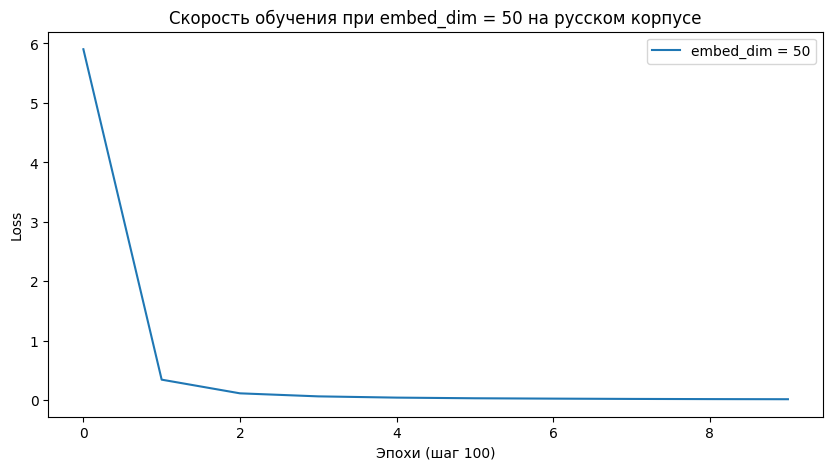

In [45]:
resultss = [5.899, 0.344, 0.114, 0.063, 0.042, 0.031, 0.025, 0.020, 0.017, 0.015]

plt.figure(figsize=(10, 5))
plt.plot(resultss, label='embed_dim = 50')
plt.xlabel('Эпохи (шаг 100)')
plt.ylabel('Loss')
plt.legend()
plt.title('Скорость обучения при embed_dim = 50 на русском корпусе')
plt.show()

In [47]:
test_corpus = ["Я приобрету кредитную карту Альфа-Банк", "Сбербанк предоставил новые акции в инвестициях"]
test_sentences = [s.lower().split() for s in test_corpus]
test_labels = [[0, 0, 0, 0, 1], [1, 0, 0, 0, 0, 1]]

# Create a test loader
test_data = list(zip(test_sentences, test_labels))
batch_size = 1
shuffle = False
window_size = 2
collate_fn = partial(custom_collate_fn, window_size=2, word_to_ix=word_to_ix_new)
test_loader = torch.utils.data.DataLoader(test_data,
                                           batch_size=1,
                                           shuffle=False,
                                           collate_fn=collate_fn)

for x in test_loader:
  print(x)

(tensor([[ 0,  0, 91,  1,  1,  1,  1,  0,  0]]), tensor([[0, 0, 0, 0, 1]]), tensor([5]))
(tensor([[ 0,  0, 72,  1,  1,  2,  5,  1,  0,  0]]), tensor([[1, 0, 0, 0, 0, 1]]), tensor([6]))


In [49]:
for test_instance, labels, _ in test_loader:
  outputs = model.forward(test_instance)
  print(f"Истинные метки: {labels}")
  print(f"Предсказанные p(w is `ORGANIZATION`):\n{outputs}")
  print('*'*32)

Истинные метки: tensor([[0, 0, 0, 0, 1]])
Предсказанные p(w is `ORGANIZATION`):
tensor([[5.9557e-04, 4.6438e-05, 6.8609e-05, 9.5806e-04, 2.3131e-03]],
       grad_fn=<ViewBackward0>)
********************************
Истинные метки: tensor([[1, 0, 0, 0, 0, 1]])
Предсказанные p(w is `ORGANIZATION`):
tensor([[1.0565e-01, 1.2652e-04, 3.1496e-04, 3.3383e-04, 5.4745e-01, 1.9616e-03]],
       grad_fn=<ViewBackward0>)
********************************
